<a href="https://colab.research.google.com/github/Lingeshkumar24-code/deep-learning/blob/main/validation_loss_DL_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective

To build a Convolutional Autoencoder (CAE) that compresses facial images into a lower-dimensional latent representation and reconstructs them with minimal loss of information.

Purpose

A Convolutional Autoencoder is an unsupervised deep learning model used for.

Image Compression Image Reconstruction Feature Extraction Dimensionality Reduction

The encoder learns a compressed representation (latent space), while the decoder reconstructs the original image from this compressed representation.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [ ]:
import os

print(os.listdir("/kaggle/input/celeba-dataset"))

['list_landmarks_align_celeba.csv', 'img_align_celeba', 'list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv']


In [ ]:
import pandas as pd

df = pd.read_csv("/kaggle/input/celeba-dataset/list_attr_celeba.csv")

print(df.head())
print(df.shape)

     image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                -1                1           1               -1   
1  000002.jpg                -1               -1          -1                1   
2  000003.jpg                -1               -1          -1               -1   
3  000004.jpg                -1               -1           1               -1   
4  000005.jpg                -1                1           1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Sideburns  Smiling  \
0    -1     -1        -1        -1          -1  ...         -1        1   
1    -1     -1        -1         1          -1  ...         -1        1   
2    -1     -1         1        -1          -1  ...         -1       -1   
3    -1     -1        -1        -1          -1  ...         -1       -1   
4    -1     -1         1        -1          -1  ...         -1       -1   

   Straight_Hair  Wavy_Hair  Wearing_Earrings  Wearing_Hat  We

# Used for interacting with the operating system
# (creating folders, accessing file paths, listing files, etc.)
import os

# Used for high-level file operations
# (copying, moving, deleting files and directories)
import shutil

# Used for numerical computations and array operations
import numpy as np

# Used for plotting graphs and displaying images
import matplotlib.pyplot as plt

# TensorFlow is the main deep learning framework
import tensorflow as tf

# Used to load, preprocess, and augment image datasets
# (rescaling, rotation, zoom, flipping, etc.)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Convolutional layer
# Extracts important features such as edges, textures, and patterns from images
from tensorflow.keras.layers import Conv2D

# Max Pooling layer
# Reduces image size while preserving the most important features
# Helps reduce computation and prevents overfitting
from tensorflow.keras.layers import MaxPooling2D

# Up Sampling layer
# Increases the spatial size of feature maps
# Commonly used in autoencoders, image reconstruction, and segmentation
from tensorflow.keras.layers import UpSampling2D

# Input layer
# Defines the shape of the input image for the neural network
from tensorflow.keras.layers import Input

# Model class
# Used to build and define a deep learning model using the Functional API
from tensorflow.keras.models import Model

In [ ]:
import os
import shutil #it is used to copying the file
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model


In [ ]:
source_folder = os.path.join(path, "img_align_celeba", "img_align_celeba")
destination_folder = "celeba_small/faces"
os.makedirs(destination_folder, exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]

for img in images :
  shutil.copy(
      os.path.join(source_folder,img),
      destination_folder
  )

In [ ]:
print("Copied",len(images),"images")

Copied 5000 images


In [ ]:
IMAGE_SIZE = (64,64) #quality of image getting that much sample for better standared quality"
BATCH_SIZE =32   # number of batches epho runs 4000/32 = 125 batch zise

In [ ]:
datagen = ImageDataGenerator(rescale=1./255 , validation_split=0.2)

In [ ]:
train_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [ ]:
validation_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


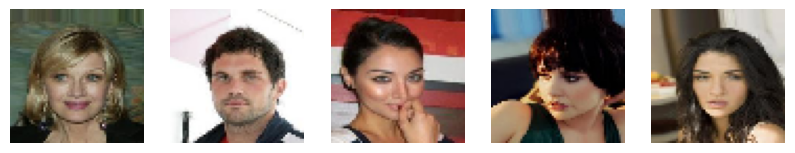

In [ ]:
images,_ = next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(images[i])
  plt.axis("off")
plt.show()

In [ ]:
#Build Convoultion Autoencoder # Encoder
imput_img = Input(shape=(64,64,3)) #64 64 is the image size and 3 is RGB
x = Conv2D(32,(3,3),activation="relu",padding="same")(imput_img) #32 is the filtration and 3,3 is the first matrix like from that get important feature
x = MaxPooling2D((2,2),padding="same")(x)
x = Conv2D(32,(3,3),activation="relu",padding="same")(x)  # 16 16 64 is the latent vectore /space
encoded = MaxPooling2D((2,2),padding="same")(x)


In [ ]:
#Decoder
x = Conv2D(64,(3,3),activation="relu",padding="same")(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32,(3,3),activation="relu",padding="same")(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(3,(3,3),activation="sigmoid",padding="same")(x)

In [ ]:
#create model
autoencoder = Model(imput_img,decoded)
autoencoder.compile(optimizer="adam",loss="binary_crossentropy")# we can use MSE but coz it use actual -predicted
# we r just generating classifciation we wont use sparese cross entropy

In [ ]:
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,971 (187.39 KB)

 Trainable params: 47,971 (187.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.5273 - val_loss: 0.4966
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4937 - val_loss: 0.4907
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.4900 - val_loss: 0.4883
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.4879 - val_loss: 0.4876
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4866 - val_loss: 0.4863
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.4864 - val_loss: 0.4875
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.4854 - val_loss: 0.4851
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.4847 - val_loss: 0.4855
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.4846 - val_loss: 0.4843
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.4840 - val_loss: 0.4840


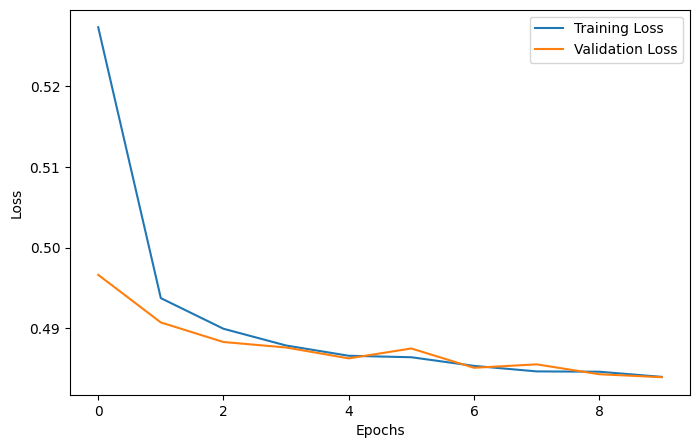

In [ ]:
#plt loss graph
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:

#evaluate model
loss = autoencoder.evaluate(validation_generator)
print("Validation Loss:",loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.4840
Validation Loss: 0.483951598405838


In [ ]:
#Reconstruct Images
images,_ = next(validation_generator)
reconstructed_images = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step


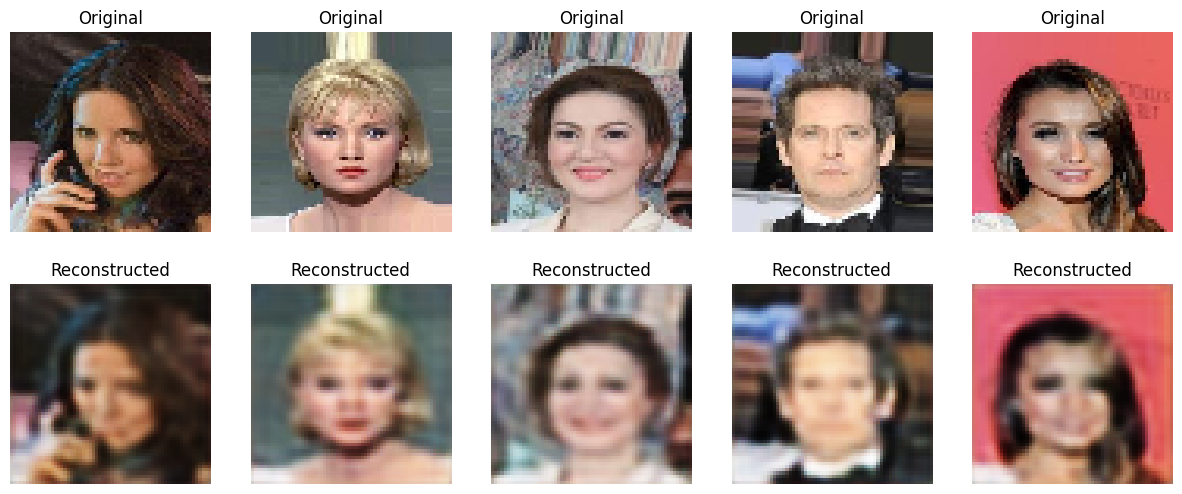

In [ ]:
#Display Results
n = 5
plt.figure(figsize = (15,6))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.title("Original")
  plt.axis("off")
  plt.subplot(2,n,i+1+n)
  plt.imshow(reconstructed_images[i])
  plt.title("Reconstructed")
  plt.axis("off")
plt.show()


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [ ]:
baseline_loss = autoencoder.evaluate(validation_generator, verbose=1)

print(f"\nBaseline Validation Loss: {baseline_loss:.6f}")

target_reduction = 15   # Change this value if required

target_loss = baseline_loss * (1 - target_reduction/100)

print(f"Target Validation Loss ({target_reduction}% reduction): {target_loss:.6f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.4840

Baseline Validation Loss: 0.483952
Target Validation Loss (15% reduction): 0.411359


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Learning Rate": [0.0005],
    "Epochs": [20],
    "Train Loss": [min(history.history["loss"])],
    "Validation Loss": [min(history.history["val_loss"])]
})

print(results_df)

   Learning Rate  Epochs  Train Loss  Validation Loss
0         0.0005      20    0.480857         0.481079


In [ ]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(
    learning_rate=0.0001
)

autoencoder.compile(
    optimizer=optimizer,
    loss="binary_crossentropy"
)

In [ ]:
from tensorflow.keras.optimizers import Adam

autoencoder.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
history2 = autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

Epoch 1/30
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0041 - mae: 0.0405
Epoch 1: val_loss improved from None to 0.00398, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - loss: 0.0041 - mae: 0.0403 - val_loss: 0.0040 - val_mae: 0.0398 - learning_rate: 1.0000e-04
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0040 - mae: 0.0398
Epoch 2: val_loss improved from 0.00398 to 0.00396, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0040 - mae: 0.0400 - val_loss: 0.0040 - val_mae: 0.0397 - learning_rate: 1.0000e-04
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0040 - mae: 0.0399
Epoch 3: val_loss improved from 0.00396 to 0.00394, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0040 - mae: 0.0400 - v

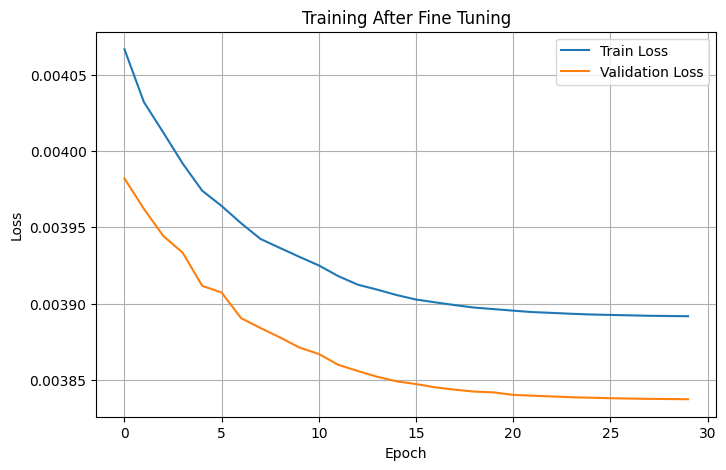

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training After Fine Tuning")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("Best Validation Loss:",val_loss)

Best Validation Loss: 0.47815531492233276


In [ ]:
best_val_loss = min(history2.history['val_loss'])

print("Best Validation Loss:", best_val_loss)

Best Validation Loss: 0.003837345400825143


Hyperparameter Tuning: To improve the performance of the Convolutional Autoencoder and reduce the validation loss, several hyperparameters were modified during training. The learning rate of the Adam optimizer was reduced from 0.001 to 0.0001 to enable smaller and more stable weight updates, helping the model converge more effectively. The loss function was changed from Binary Cross-Entropy (BCE) to Mean Squared Error (MSE), as MSE is better suited for image reconstruction tasks by minimizing the pixel-wise difference between the input and reconstructed images. The number of training epochs was increased from 20 to 30 (or higher) to allow the model more time to learn meaningful image features. Additionally, EarlyStopping was introduced to stop training automatically when the validation loss stopped improving, preventing overfitting. A ReduceLROnPlateau callback was added to automatically decrease the learning rate whenever the validation loss plateaued, enabling the model to continue learning effectively. Finally, ModelCheckpoint was used to save the model with the lowest validation loss during training, ensuring that the best-performing model was retained for evaluation. These hyperparameter changes were made to improve training stability, enhance generalization, and achieve better reconstruction performance.